
## Part III: Natural Language Processing Task
### Sarcasm Detection in News Headlines using RNN, LSTM, and Word2Vec (GloVe) Embeddings




## Section 1 - Environment Setup & Library Imports


In [ ]:
!pip install gradio -q
!pip install gensim -q
!pip install wordcloud -q
print("All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.9 MB/s eta 0:00:00
All libraries installed successfully!


In [ ]:
# Core Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time, re, os
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

# WordCloud
from wordcloud import WordCloud
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics         import (classification_report,
                                     confusion_matrix,
                                     accuracy_score,
                                     precision_score,
                                     recall_score,
                                     f1_score)

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.models               import Sequential
from tensorflow.keras.layers               import (Embedding, SimpleRNN, LSTM,
                                                    Dense, Dropout, Bidirectional,
                                                    BatchNormalization)
from tensorflow.keras.preprocessing.text   import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks            import (EarlyStopping,
                                                    ReduceLROnPlateau,
                                                    ModelCheckpoint)
from tensorflow.keras.optimizers           import Adam

# Gensim
import gensim.downloader as api

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy    version   : {np.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
NumPy    version   : 2.0.2
GPU available      : False



## Section 2 - Dataset Loading & Exploratory Data Analysis

**Dataset:** Sarcastic News Headlines (binary classification)
- `headline` - The news headline text
- `is_sarcastic` - Binary label: `1` = Sarcastic, `0` = Not Sarcastic

In [ ]:
# Mount Google Drive & Extract ZIP
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

ZIP_PATH    = '/content/drive/MyDrive/AI zip file/Sarcastic or Not Sarcastic Dataset.zip'
EXTRACT_DIR = '/content/dataset/'

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
    print("Files extracted:")
    for name in z.namelist():
        print(f"  {name}")

CSV_PATH = os.path.join(EXTRACT_DIR, '8. Sarcastic or Not Sarcastic Dataset', 'sarcastic_headlines.csv')
df = pd.read_csv(CSV_PATH)

print("\n   DATASET OVERVIEW")
print(f"  Total records    : {len(df):,}")
print(f"  Columns          : {list(df.columns)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum()}")
display(df.head(10))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files extracted:
  8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv
  8. Sarcastic or Not Sarcastic Dataset/8.Description Sarcastic or Not Dataset.txt

   DATASET OVERVIEW
  Total records    : 28,619
  Columns          : ['headline', 'is_sarcastic']
  Missing values   : 0
  Duplicate rows   : 116


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1
5,my white inheritance,0
6,5 ways to file your taxes with less stress,0
7,richard branson's global-warming donation near...,1
8,shadow government getting too large to meet in...,1
9,lots of parents know this scenario,0


Class Distribution:
is_sarcastic
Not Sarcastic    14985
Sarcastic        13634

Balance ratio: 0.910 (sarcastic:non-sarcastic)


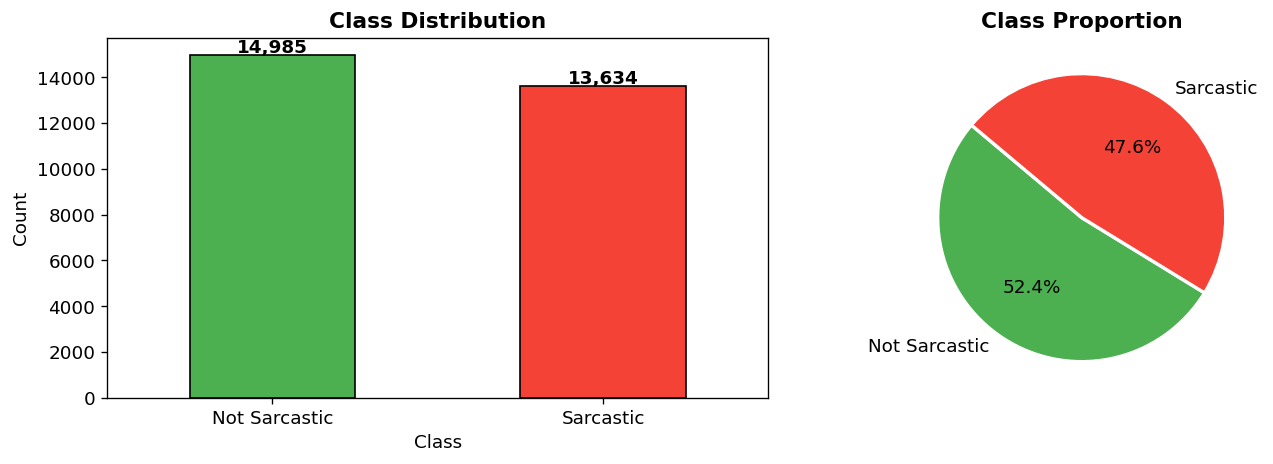


 Observation: The dataset is nearly balanced (~47.6% sarcastic vs 52.4% non-sarcastic), which eliminates the need for oversampling/undersampling techniques.


In [ ]:
# Class Distribution
class_counts = df['is_sarcastic'].value_counts().rename({0: 'Not Sarcastic', 1: 'Sarcastic'})
print("Class Distribution:")
print(class_counts.to_string())
print(f"\nBalance ratio: {class_counts[1]/class_counts[0]:.3f} (sarcastic:non-sarcastic)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4CAF50', '#F44336']
class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(class_counts.index, rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 100),
                     ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()
print("\n Observation: The dataset is nearly balanced (~47.6% sarcastic vs 52.4% non-sarcastic),",
      "which eliminates the need for oversampling/undersampling techniques.")

Word Count Statistics by Class:
                count   mean   std  min  25%   50%   75%    max
is_sarcastic                                                   
0             14985.0   9.82  2.89  2.0  8.0  10.0  12.0   38.0
1             13634.0  10.31  3.85  2.0  8.0  10.0  13.0  151.0


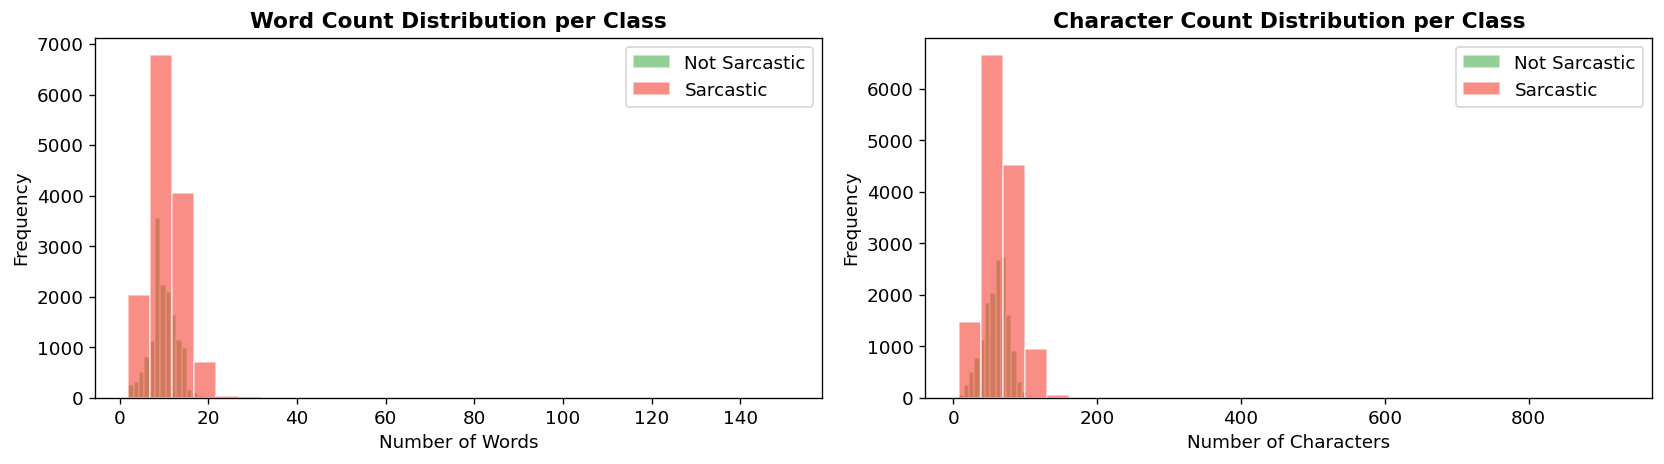


 Observation: Sarcastic headlines tend to be slightly longer on average, suggesting sarcasm is often expressed through more elaborate phrasing.


In [ ]:
# Headline Length Analysis
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['headline'].apply(lambda x: len(str(x)))

print("Word Count Statistics by Class:")
print(df.groupby('is_sarcastic')['word_count'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in [(0, '#4CAF50', 'Not Sarcastic'), (1, '#F44336', 'Sarcastic')]:
    subset = df[df['is_sarcastic'] == label]['word_count']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor='white')
    axes[1].hist(df[df['is_sarcastic'] == label]['char_count'],
                 bins=30, alpha=0.6, color=color, label=name, edgecolor='white')

axes[0].set_title('Word Count Distribution per Class')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Character Count Distribution per Class')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('length_distribution.png', bbox_inches='tight')
plt.show()
print("\n Observation: Sarcastic headlines tend to be slightly longer on average,",
      "suggesting sarcasm is often expressed through more elaborate phrasing.")


## Section 3 - Text Preprocessing & Cleaning

The following preprocessing pipeline is applied sequentially:
1. **Lowercase** all text for uniformity
2. **Remove URLs**, mentions (`@user`), hashtags (`#`), numbers, special characters
3. **Expand contractions** (e.g., `don't` → `do not`)
4. **Remove stopwords** using NLTK English stopwords
5. **Lemmatize** words to reduce them to their base/dictionary form

In [ ]:
# Contraction Mapping (comprehensive list)
CONTRACTIONS = {
    "ain't": "am not", "aren't": "are not", "can't": "cannot",
    "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he'd": "he would", "he'll": "he will",
    "he's": "he is", "i'd": "i would", "i'll": "i will",
    "i'm": "i am", "i've": "i have", "isn't": "is not",
    "it's": "it is", "let's": "let us", "mustn't": "must not",
    "shan't": "shall not", "she'd": "she would", "she'll": "she will",
    "she's": "she is", "shouldn't": "should not", "that's": "that is",
    "there's": "there is", "they'd": "they would", "they'll": "they will",
    "they're": "they are", "they've": "they have", "wasn't": "was not",
    "we'd": "we would", "we're": "we are", "we've": "we have",
    "weren't": "were not", "what'll": "what will", "what're": "what are",
    "what's": "what is", "what've": "what have", "where's": "where is",
    "who's": "who is", "won't": "will not", "wouldn't": "would not",
    "you'd": "you would", "you'll": "you will", "you're": "you are",
    "you've": "you have"
}

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)
    return text

# Preprocessing Function
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()                       # 1. Lowercase
    text = re.sub(r'http\S+|www\S+', '', text)    # 2. Remove URLs
    text = re.sub(r'@\w+', '', text)               # 2. Remove mentions
    text = re.sub(r'#\w+', '', text)               # 2. Remove hashtags
    text = expand_contractions(text)                # 3. Expand contractions
    text = re.sub(r'[^a-z\s]', '', text)           # 4. Remove non-alpha chars
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w)              # 5. Lemmatize
              for w in tokens
              if w not in STOP_WORDS and len(w) > 2]  # Remove stopwords + short tokens
    return ' '.join(tokens)

# Apply to dataset
print("Cleaning text... (this may take ~30s on CPU)")
t0 = time.time()
df['cleaned_headline'] = df['headline'].apply(clean_text)
print(f"Done in {time.time()-t0:.1f}s")

# Preview results
print("\n Sample: Original vs Cleaned")
for i in range(5):
    lbl = 'SARCASTIC' if df['is_sarcastic'].iloc[i] == 1 else 'NOT SARCASTIC'
    print(f"[{lbl}]")
    print(f"  Original : {df['headline'].iloc[i]}")
    print(f"  Cleaned  : {df['cleaned_headline'].iloc[i]}\n")

Cleaning text... (this may take ~30s on CPU)
Done in 3.7s

 Sample: Original vs Cleaned
[SARCASTIC]
  Original : thirtysomething scientists unveil doomsday clock of hair loss
  Cleaned  : thirtysomething scientist unveil doomsday clock hair loss

[NOT SARCASTIC]
  Original : dem rep. totally nails why congress is falling short on gender, racial equality
  Cleaned  : dem rep totally nail congress falling short gender racial equality

[NOT SARCASTIC]
  Original : eat your veggies: 9 deliciously different recipes
  Cleaned  : eat veggie deliciously different recipe

[SARCASTIC]
  Original : inclement weather prevents liar from getting to work
  Cleaned  : inclement weather prevents liar getting work

[SARCASTIC]
  Original : mother comes pretty close to using word 'streaming' correctly
  Cleaned  : mother come pretty close using word streaming correctly




## Section 4 - Visualization: Word Cloud & Top Frequent Words

Word clouds and frequency charts help us understand which words are most predictive of each class.

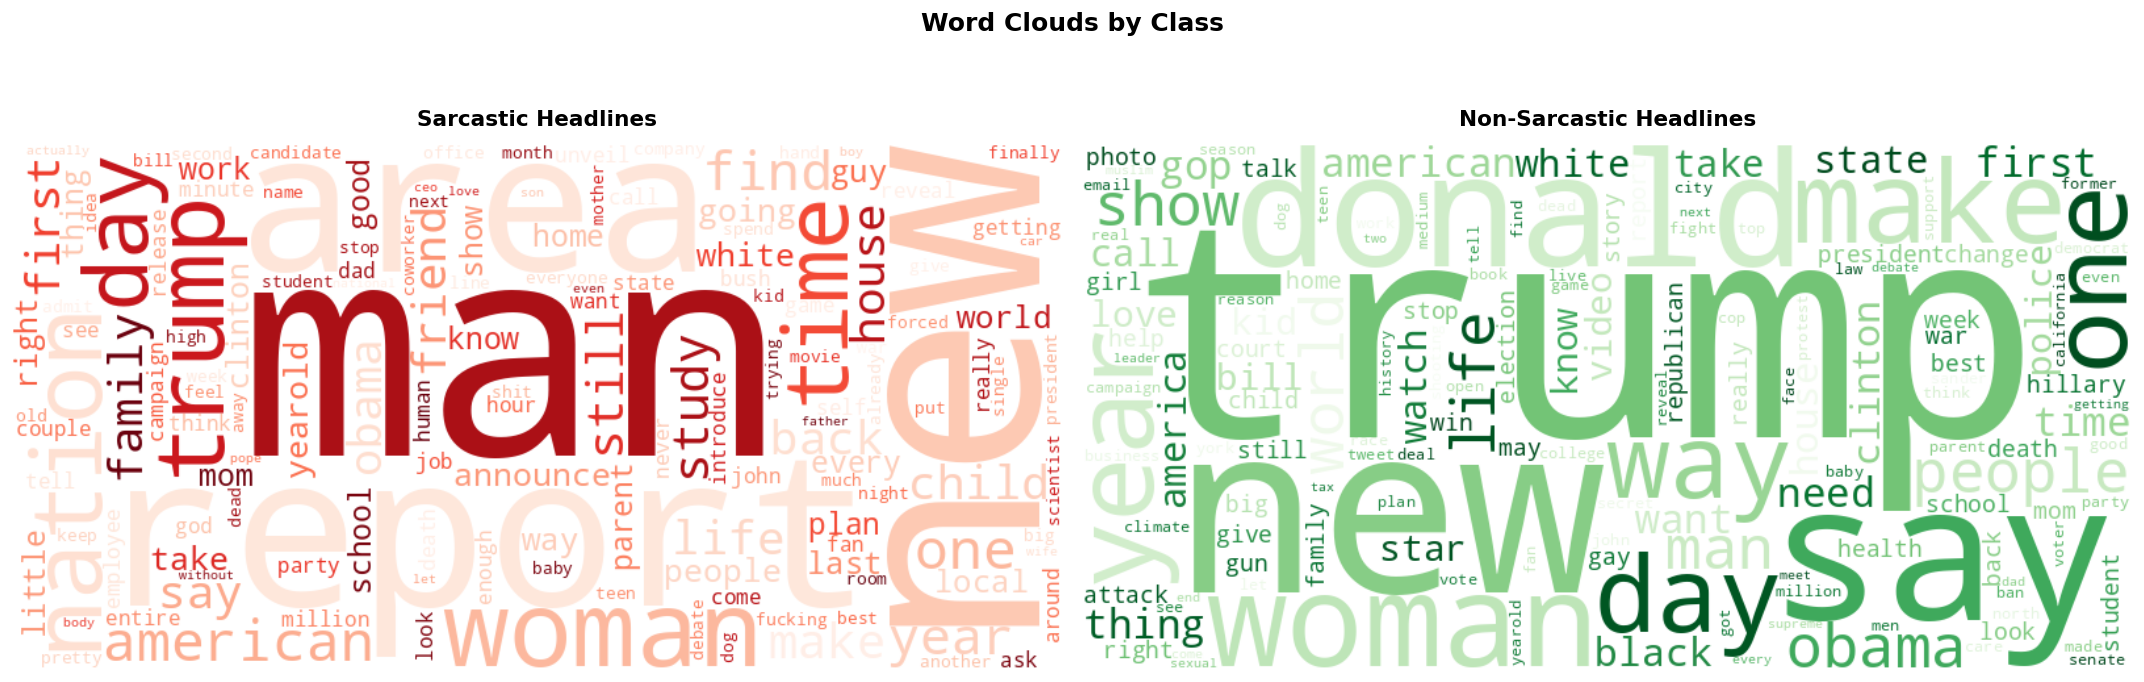

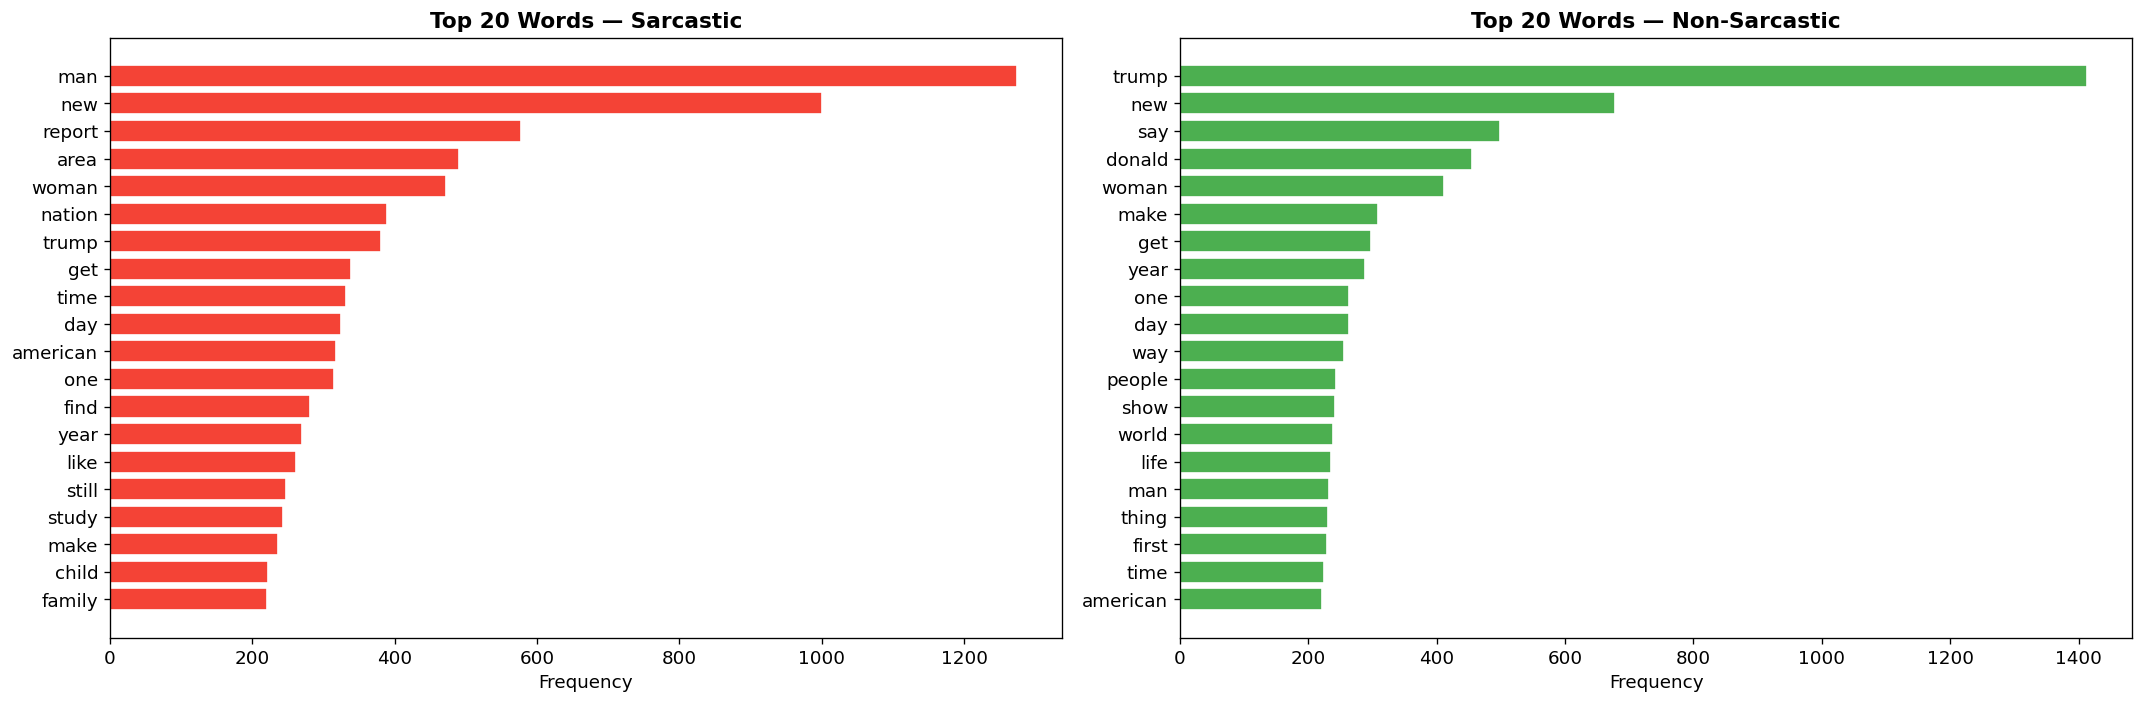


 Observation: Sarcastic headlines frequently contain words like 'man', 'new', 'report', and 'area' — often used in ironic or absurdist contexts.


In [ ]:
# Word Clouds per Class
sarc_text    = ' '.join(df[df['is_sarcastic']==1]['cleaned_headline'])
nonsarc_text = ' '.join(df[df['is_sarcastic']==0]['cleaned_headline'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, text, title, cmap in [
        (axes[0], sarc_text,    'Sarcastic Headlines',     'Reds'),
        (axes[1], nonsarc_text, 'Non-Sarcastic Headlines', 'Greens')]:
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=150, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, pad=12)
plt.suptitle('Word Clouds by Class', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()

# Top 20 Frequent Words per Class
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, text, title, color in [
        (axes[0], sarc_text,    'Top 20 Words — Sarcastic',     '#F44336'),
        (axes[1], nonsarc_text, 'Top 20 Words — Non-Sarcastic', '#4CAF50')]:
    freq = Counter(text.split()).most_common(20)
    words, counts = zip(*freq)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('top_words.png', bbox_inches='tight')
plt.show()
print("\n Observation: Sarcastic headlines frequently contain words like 'man', 'new',",
      "'report', and 'area' — often used in ironic or absurdist contexts.")


## Section 5 - Tokenization, Train/Test Split & Sequence Padding

- **80/20 split** ensures class balance is maintained in both sets.
- **Keras Tokenizer** is fit only on training data to prevent data leakage.
- **Percentile-based padding** (95th percentile) avoids excessively long padded sequences.

In [ ]:
# Parameters
VOCAB_SIZE = 20000
OOV_TOKEN  = '<OOV>'

# Percentile-based padding to avoid excessively long sequences
word_counts = df['cleaned_headline'].apply(lambda x: len(x.split()))
MAX_LEN     = int(np.percentile(word_counts, 95))  # 95th percentile
print(f"Max sequence length (95th percentile): {MAX_LEN} words")
print(f"Mean headline length: {word_counts.mean():.1f} words")
print(f"Max  headline length: {word_counts.max()} words")

# Train / Test Split (80/20, stratified)
X = df['cleaned_headline'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"\nTrain size : {len(X_train):,}")
print(f"Test  size : {len(X_test):,}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)}")

# Tokenizer- fit ONLY on training data (prevents data leakage)
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
VOCAB_SIZE  = min(VOCAB_SIZE, len(word_index) + 1)
print(f"\nVocabulary size (fitted): {len(word_index):,}")
print(f"Vocabulary size (used)  : {VOCAB_SIZE:,}")

# Convert text → integer sequences
train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

# Padding (post-padding, post-truncation)
X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

Max sequence length (95th percentile): 11 words
Mean headline length: 7.0 words
Max  headline length: 106 words

Train size : 22,895
Test  size : 5,724
Train class balance: [11988 10907]
Test  class balance: [2997 2727]

Vocabulary size (fitted): 22,397
Vocabulary size (used)  : 20,000

X_train_pad shape : (22895, 11)
X_test_pad  shape : (5724, 11)


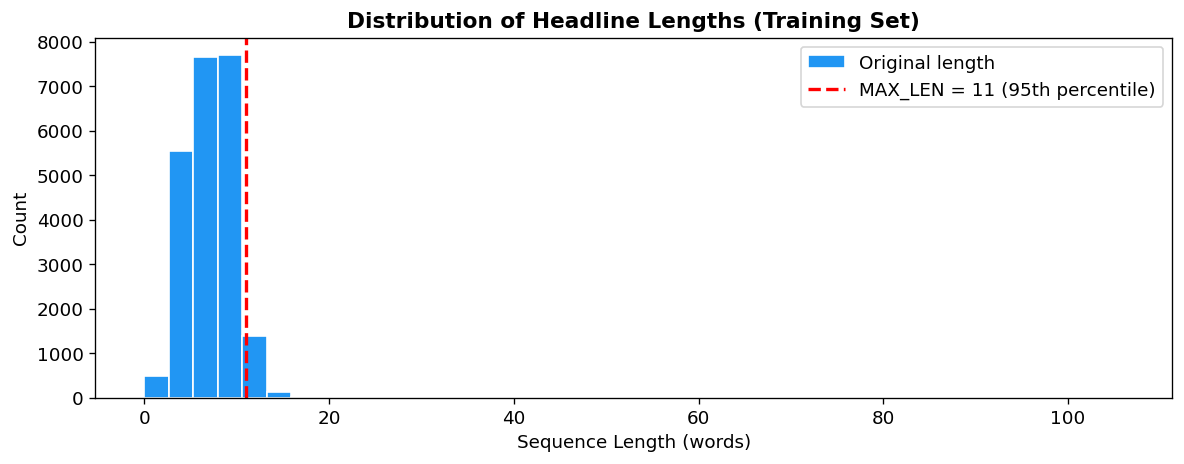

95th-percentile cutoff (11 tokens) covers the vast majority of headlines, trimming only the longest 5% to avoid unnecessary padding overhead.


In [ ]:
# Visualise padding lengths
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist([len(s) for s in train_seqs], bins=40, color='#2196F3', edgecolor='white', label='Original length')
ax.axvline(MAX_LEN, color='red', linestyle='--', lw=2, label=f'MAX_LEN = {MAX_LEN} (95th percentile)')
ax.set_title('Distribution of Headline Lengths (Training Set)')
ax.set_xlabel('Sequence Length (words)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', bbox_inches='tight')
plt.show()
print(f"95th-percentile cutoff ({MAX_LEN} tokens) covers the vast majority of headlines,",
      "trimming only the longest 5% to avoid unnecessary padding overhead.")

## Section 6 - Model 1: Simple RNN with Trainable Embedding

A vanilla Recurrent Neural Network with a trainable embedding layer.
RNNs process sequences step-by-step, maintaining a hidden state, but suffer from the **vanishing gradient problem** for long sequences making them less effective at capturing long-range dependencies compared to LSTMs.

In [ ]:
# Shared Hyperparameters (used across all models)
EMBEDDING_DIM = 64
RNN_UNITS     = 64
DROPOUT_RATE  = 0.3
BATCH_SIZE    = 128
EPOCHS        = 20

# Build Model 1: Simple RNN
def build_rnn_model():
    model = Sequential(name='Model_1_SimpleRNN')
    model.add(Embedding(input_dim=VOCAB_SIZE,
                        output_dim=EMBEDDING_DIM,
                        input_length=MAX_LEN,
                        name='embedding_rnn'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(SimpleRNN(RNN_UNITS, return_sequences=False, name='simple_rnn'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(32, activation='relu', name='dense_hidden'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(1, activation='sigmoid', name='output'))

    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model1 = build_rnn_model()
model1.build(input_shape=(None, MAX_LEN)) # Explicitly build the model
model1.summary()
print(f"\nModel 1 total parameters: {model1.count_params():,}")

Model: "Model_1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ (None, 11, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,290,369 (4.92 MB)

 Trainable params: 1,290,369 (4.92 MB)

 Non-trainable params: 0 (0.00 B)


Model 1 total parameters: 1,290,369


Training Model 1: Simple RNN...
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7041 - loss: 0.5583 - val_accuracy: 0.7956 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8807 - loss: 0.2932 - val_accuracy: 0.8039 - val_loss: 0.4505 - learning_rate: 0.0010
Epoch 3/20
158/161 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9371 - loss: 0.1679
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9465 - loss: 0.1465 - val_accuracy: 0.7991 - val_loss: 0.5784 - learning_rate: 0.0010
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9745 - loss: 0.0722 - val_accuracy: 0.8052 - val_loss: 0.6631 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

 Model 1 training completed in 12.8s (4 epochs)


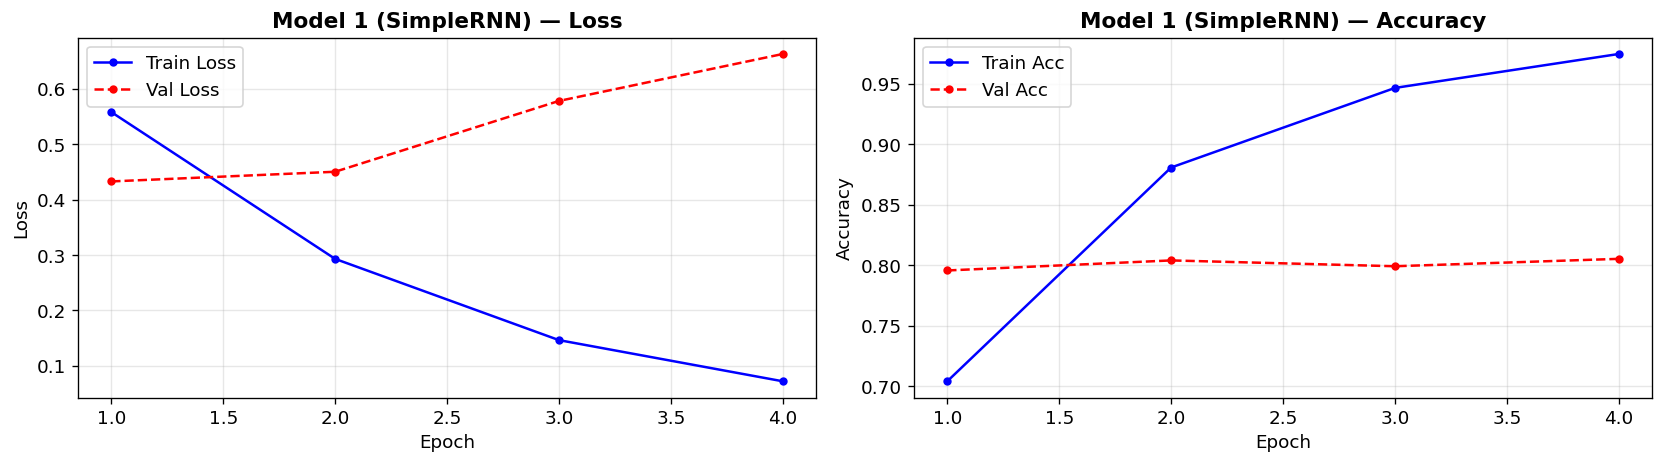

In [ ]:
# Train Model 1
print("Training Model 1: Simple RNN...")
t0 = time.time()
history1 = model1.fit(
    X_train_pad, y_train,
    validation_split=0.10,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)
    ],
    verbose=1
)
model1_train_time = time.time() - t0
model1_epochs     = len(history1.history['loss'])
print(f"\n Model 1 training completed in {model1_train_time:.1f}s ({model1_epochs} epochs)")

# Individual Training Curve: Model 1
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, model1_epochs + 1)
axes[0].plot(ep, history1.history['loss'],     'b-o', ms=4, label='Train Loss')
axes[0].plot(ep, history1.history['val_loss'], 'r--o', ms=4, label='Val Loss')
axes[0].set_title('Model 1 (SimpleRNN) — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history1.history['accuracy'],     'b-o', ms=4, label='Train Acc')
axes[1].plot(ep, history1.history['val_accuracy'], 'r--o', ms=4, label='Val Acc')
axes[1].set_title('Model 1 (SimpleRNN) — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('history_model1.png', bbox_inches='tight')
plt.show()

  EVALUATION REPORT: Model 1: Simple RNN
  Test Accuracy : 0.7841 (78.41%)

  Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.75      0.88      0.81      2997
    Sarcastic       0.84      0.68      0.75      2727

     accuracy                           0.78      5724
    macro avg       0.79      0.78      0.78      5724
 weighted avg       0.79      0.78      0.78      5724



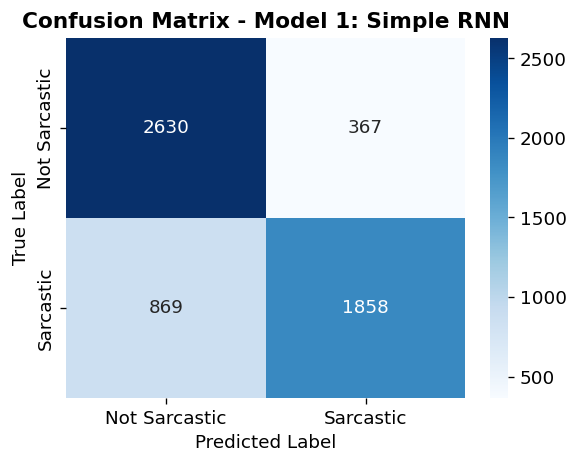

In [ ]:
# Shared Evaluation Function
def evaluate_model(model, X_test, y_test, model_name='Model'):
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred      = (y_pred_prob > 0.5).astype(int)
    acc         = accuracy_score(y_test, y_pred)

    print(f"  EVALUATION REPORT: {model_name}")
    print(f"  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=['Not Sarcastic', 'Sarcastic']))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Sarcastic', 'Sarcastic'],
                yticklabels=['Not Sarcastic', 'Sarcastic'])
    ax.set_title(f'Confusion Matrix - {model_name}')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', bbox_inches='tight')
    plt.show()

    return {'name': model_name, 'accuracy': acc,
            'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'cm': cm,
            'params': model.count_params()}

results1 = evaluate_model(model1, X_test_pad, y_test, 'Model 1: Simple RNN')


## Section 7 - Model 2: LSTM with Trainable Embedding

LSTM (Long Short-Term Memory) uses **gates** (input, forget, output) to selectively remember or forget information, effectively solving the vanishing gradient problem of vanilla RNNs.
A 2-layer stacked LSTM is used to capture both short- and long-range sequential dependencies in the text.

In [ ]:
def build_lstm_model():
    model = Sequential(name='Model_2_LSTM')
    model.add(Embedding(input_dim=VOCAB_SIZE,
                        output_dim=EMBEDDING_DIM,
                        input_length=MAX_LEN,
                        name='embedding_lstm'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(LSTM(128, return_sequences=True, name='lstm_1'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(LSTM(64, return_sequences=False, name='lstm_2'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(32, activation='relu', name='dense_hidden'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(1, activation='sigmoid', name='output'))

    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model2 = build_lstm_model()
model2.build(input_shape=(None, MAX_LEN)) # Explicitly build the model
model2.summary()
print(f"\nModel 2 total parameters: {model2.count_params():,}")

Model: "Model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ (None, 11, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 11, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,430,337 (5.46 MB)

 Trainable params: 1,430,337 (5.46 MB)

 Non-trainable params: 0 (0.00 B)


Model 2 total parameters: 1,430,337


Training Model 2: LSTM...
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.7257 - loss: 0.5333 - val_accuracy: 0.8000 - val_loss: 0.4333 - learning_rate: 0.0010
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8685 - loss: 0.3162 - val_accuracy: 0.8009 - val_loss: 0.4456 - learning_rate: 0.0010
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9161 - loss: 0.2207
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9243 - loss: 0.2015 - val_accuracy: 0.7821 - val_loss: 0.6219 - learning_rate: 0.0010
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9564 - loss: 0.1236 - val_accuracy: 0.7721 - val_loss: 0.6955 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

 Model 2 training completed in 41.8s (4 epochs)


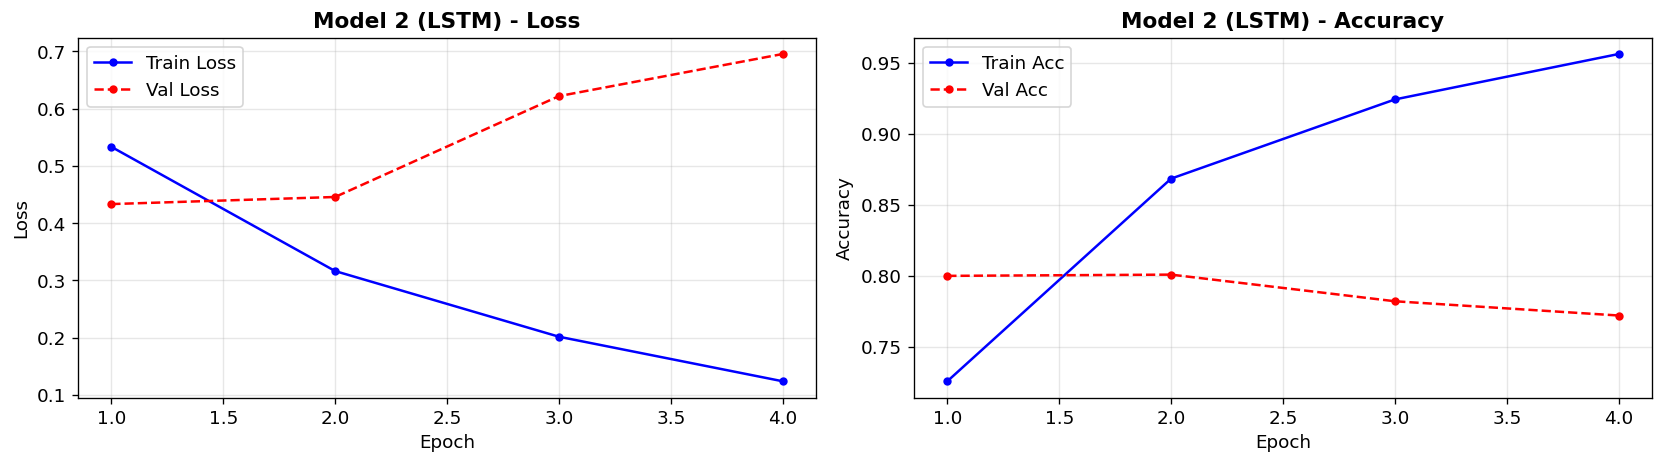

  EVALUATION REPORT: Model 2: LSTM
  Test Accuracy : 0.7926 (79.26%)

  Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.78      0.84      0.81      2997
    Sarcastic       0.81      0.74      0.77      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



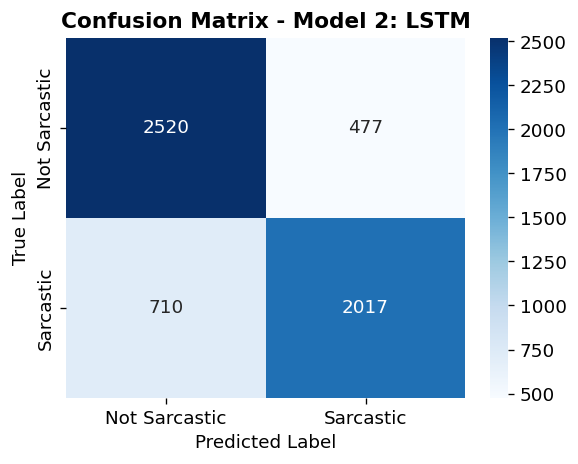

In [ ]:
print("Training Model 2: LSTM...")
t0 = time.time()
history2 = model2.fit(
    X_train_pad, y_train,
    validation_split=0.10,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)
    ],
    verbose=1
)
model2_train_time = time.time() - t0
model2_epochs     = len(history2.history['loss'])
print(f"\n Model 2 training completed in {model2_train_time:.1f}s ({model2_epochs} epochs)")

# Individual Training Curve: Model 2
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, model2_epochs + 1)
axes[0].plot(ep, history2.history['loss'],     'b-o', ms=4, label='Train Loss')
axes[0].plot(ep, history2.history['val_loss'], 'r--o', ms=4, label='Val Loss')
axes[0].set_title('Model 2 (LSTM) - Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history2.history['accuracy'],     'b-o', ms=4, label='Train Acc')
axes[1].plot(ep, history2.history['val_accuracy'], 'r--o', ms=4, label='Val Acc')
axes[1].set_title('Model 2 (LSTM) - Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('history_model2.png', bbox_inches='tight')
plt.show()

results2 = evaluate_model(model2, X_test_pad, y_test, 'Model 2: LSTM')


## Section 8 - Model 3: LSTM with Pre-trained GloVe (Word2Vec) Embeddings

Instead of learning word vectors from scratch, Model 3 uses GloVe embeddings (`glove-wiki-gigaword-100`, 100-dimensional) pre-trained on billions of words from Wikipedia and Gigaword.
This provides richer, semantically aware word representations especially beneficial for a dataset of short headlines where each word carries high information density.

In [ ]:
print("Downloading GloVe embeddings (glove-wiki-gigaword-100)...")
print("This may take 2-5 minutes on first run.")
t0 = time.time()
embedding_model = api.load('glove-wiki-gigaword-100')  # 100-dim GloVe
GLOVE_DIM = 100
print(f" Embeddings loaded in {time.time()-t0:.1f}s")
print(f"   Vocabulary size : {len(embedding_model.key_to_index):,}")
print(f"   Vector dim      : {GLOVE_DIM}")

This may take 2-5 minutes on first run.
[==================================================] 100.0% 128.1/128.1MB downloaded
 Embeddings loaded in 73.1s
   Vocabulary size : 400,000
   Vector dim      : 100


In [ ]:
# Build Embedding Matrix
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found_words, oov_words = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found_words += 1
    else:
        oov_words += 1  # Keep zero vector for OOV words

coverage = found_words / min(VOCAB_SIZE, len(word_index)) * 100
print(f"Embedding Matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found_words:,}")
print(f"OOV words              : {oov_words:,}")
print(f"Coverage               : {coverage:.2f}%")
print(f"\n High coverage ({coverage:.1f}%) means most vocabulary words have rich semantic representations.")

Embedding Matrix shape : (20000, 100)
Words found in GloVe   : 17,714
OOV words              : 2,285
Coverage               : 88.57%

 High coverage (88.6%) means most vocabulary words have rich semantic representations.


In [ ]:
def build_lstm_glove_model():
    model = Sequential(name='Model_3_LSTM_GloVe')
    # Pre-trained GloVe embedding: trainable=False (feature extraction mode)
    model.add(Embedding(input_dim=VOCAB_SIZE,
                        output_dim=GLOVE_DIM,
                        weights=[embedding_matrix],
                        input_length=MAX_LEN,
                        trainable=False,   # Frozen: preserves pre-trained semantics
                        name='glove_embedding'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(LSTM(128, return_sequences=True, name='lstm_1'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(LSTM(64, return_sequences=False, name='lstm_2'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(64, activation='relu', name='dense_1'))
    model.add(Dropout(DROPOUT_RATE))
    model.add(Dense(32, activation='relu', name='dense_2'))
    model.add(Dense(1, activation='sigmoid', name='output'))

    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model3 = build_lstm_glove_model()
model3.build(input_shape=(None, MAX_LEN)) # Explicitly build the model
model3.summary()
print(f"\nModel 3 total parameters        : {model3.count_params():,}")
print(f"Model 3 trainable parameters    : {sum(tf.size(v).numpy() for v in model3.trainable_variables):,}")
print(f"Model 3 non-trainable parameters: {sum(tf.size(v).numpy() for v in model3.non_trainable_variables):,}")

Model: "Model_3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ (None, 11, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 11, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 11, 128)        │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 11, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,172,929 (8.29 MB)

 Trainable params: 172,929 (675.50 KB)

 Non-trainable params: 2,000,000 (7.63 MB)


Model 3 total parameters        : 2,172,929
Model 3 trainable parameters    : 172,929
Model 3 non-trainable parameters: 2,000,012


Training Model 3: LSTM with GloVe Embeddings...
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8816 - loss: 0.2752 - val_accuracy: 0.8197 - val_loss: 0.4164 - learning_rate: 1.2500e-04
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.8869 - loss: 0.2670 - val_accuracy: 0.8210 - val_loss: 0.4202 - learning_rate: 1.2500e-04
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8789 - loss: 0.2744 - val_accuracy: 0.8214 - val_loss: 0.4155 - learning_rate: 1.2500e-04
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.8868 - loss: 0.2628 - val_accuracy: 0.8266 - val_loss: 0.4126 - learning_rate: 1.2500e-04
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.8885 - loss: 0.2625 - val_accuracy: 0.8249 - val_loss: 0.4208 - learning_rate: 1.2500e-04
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8876 - loss: 0.2633 - val_accuracy: 0.8266 - val_loss: 0.4100 - learning_rate: 1.2500e-04
Epoch 7/2

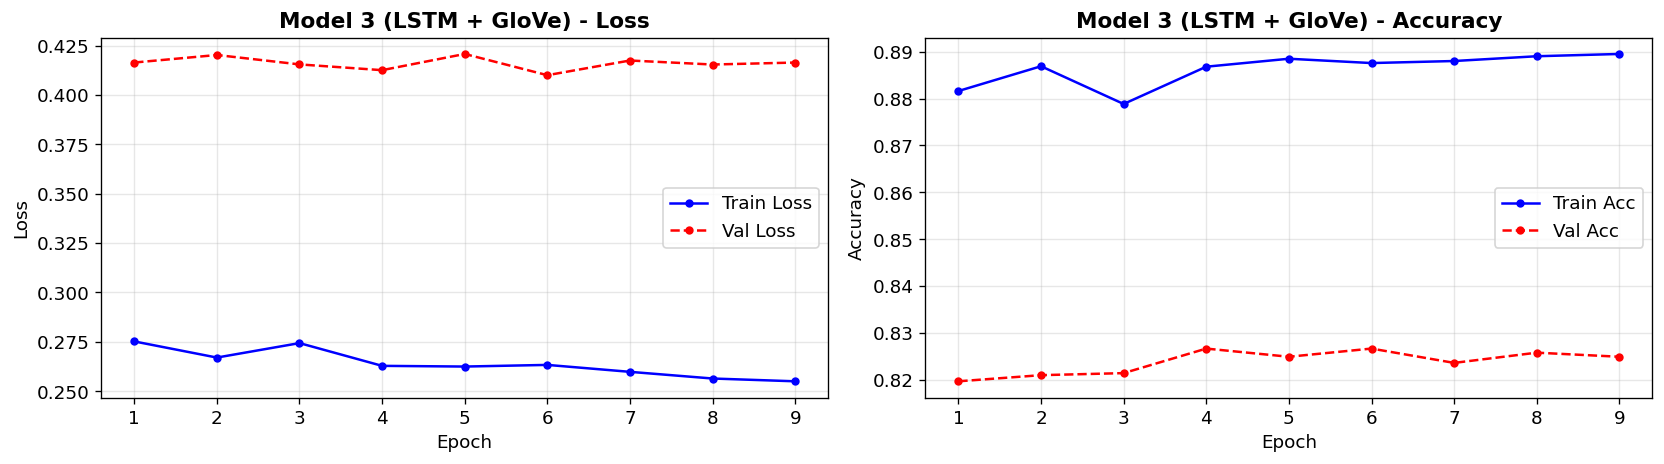

  EVALUATION REPORT: Model 3: LSTM + GloVe
  Test Accuracy : 0.8160 (81.60%)

  Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.86      0.83      2997
    Sarcastic       0.83      0.77      0.80      2727

     accuracy                           0.82      5724
    macro avg       0.82      0.81      0.81      5724
 weighted avg       0.82      0.82      0.82      5724



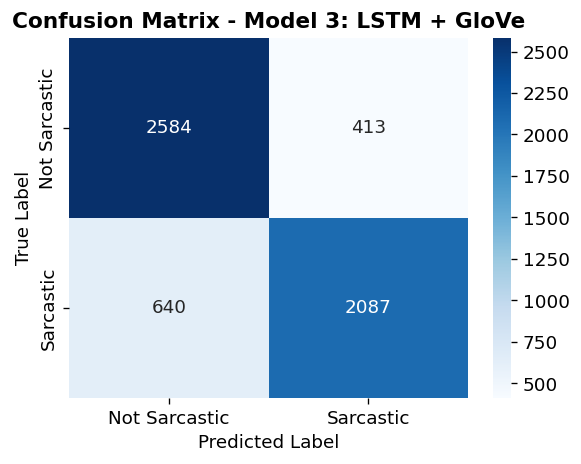

In [ ]:
print("Training Model 3: LSTM with GloVe Embeddings...")
t0 = time.time()
history3 = model3.fit(
    X_train_pad, y_train,
    validation_split=0.10,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)
    ],
    verbose=1
)
model3_train_time = time.time() - t0
model3_epochs     = len(history3.history['loss'])
print(f"\n Model 3 training completed in {model3_train_time:.1f}s ({model3_epochs} epochs)")

# Individual Training Curve: Model 3
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep = range(1, model3_epochs + 1)
axes[0].plot(ep, history3.history['loss'],     'b-o', ms=4, label='Train Loss')
axes[0].plot(ep, history3.history['val_loss'], 'r--o', ms=4, label='Val Loss')
axes[0].set_title('Model 3 (LSTM + GloVe) - Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history3.history['accuracy'],     'b-o', ms=4, label='Train Acc')
axes[1].plot(ep, history3.history['val_accuracy'], 'r--o', ms=4, label='Val Acc')
axes[1].set_title('Model 3 (LSTM + GloVe) - Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('history_model3.png', bbox_inches='tight')
plt.show()

results3 = evaluate_model(model3, X_test_pad, y_test, 'Model 3: LSTM + GloVe')


## Section 9 - Comparative Analysis: All Models

This section provides a comprehensive side-by-side comparison covering:
- Overlaid training curves (loss & accuracy) for all 3 models
- Performance metrics table (accuracy, precision, recall, F1)
- Confusion matrices side-by-side
- Training time & computational efficiency
- Model complexity vs. performance trade-off analysis

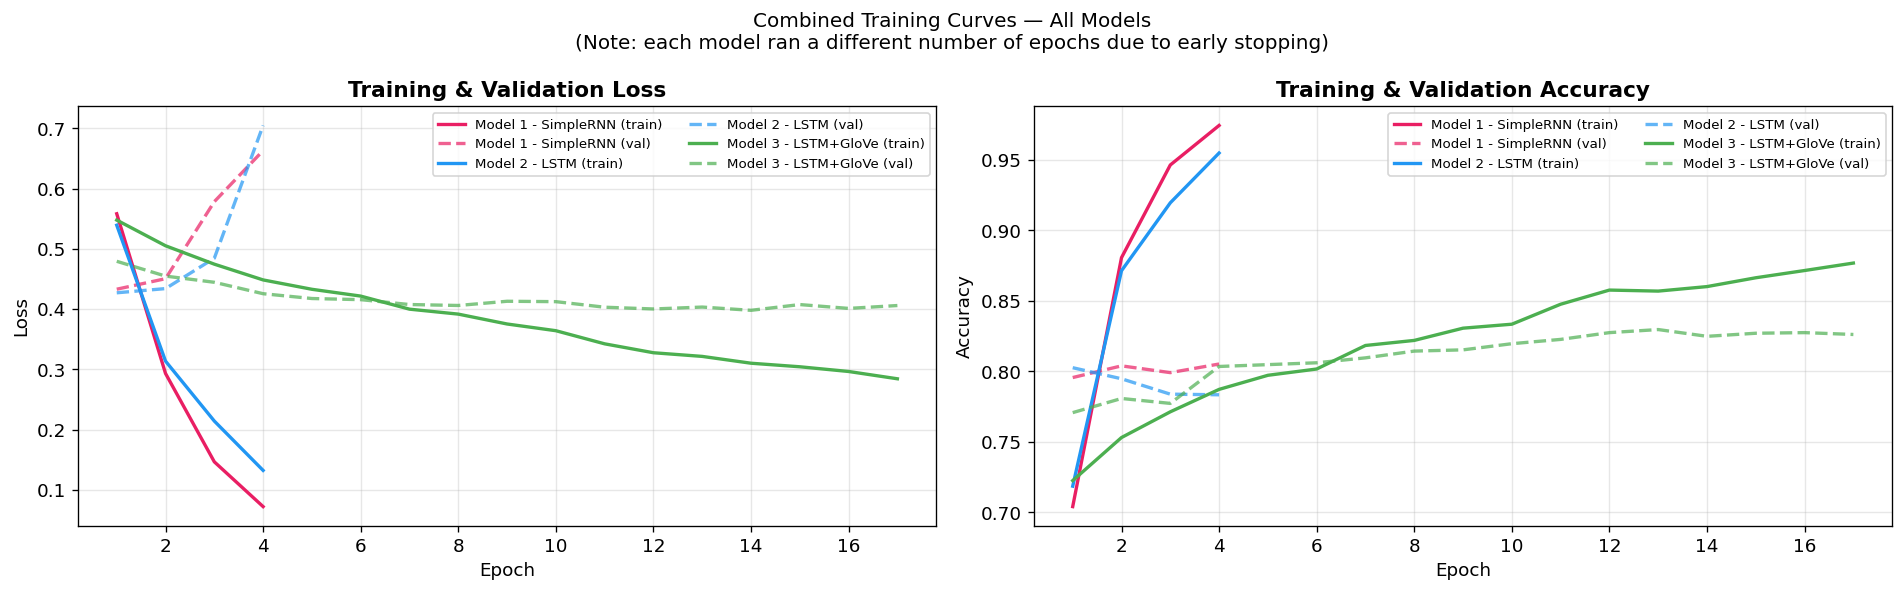

In [ ]:
# Overlaid Training Curves (All 3 Models)
histories = [
    (history1, 'Model 1 - SimpleRNN', '#E91E63', model1_epochs),
    (history2, 'Model 2 - LSTM',      '#2196F3', model2_epochs),
    (history3, 'Model 3 - LSTM+GloVe','#4CAF50', model3_epochs),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Combined Training Curves — All Models\n'
             '(Note: each model ran a different number of epochs due to early stopping)',
             fontsize=12)

for hist, name, color, n_ep in histories:
    ep = range(1, n_ep + 1)
    axes[0].plot(ep, hist.history['loss'],     color=color, linewidth=2, label=f'{name} (train)')
    axes[0].plot(ep, hist.history['val_loss'], color=color, linewidth=2, linestyle='--', alpha=0.7, label=f'{name} (val)')
    axes[1].plot(ep, hist.history['accuracy'],     color=color, linewidth=2, label=f'{name} (train)')
    axes[1].plot(ep, hist.history['val_accuracy'], color=color, linewidth=2, linestyle='--', alpha=0.7, label=f'{name} (val)')

axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8, ncol=2); axes[0].grid(alpha=0.3)

axes[1].set_title('Training & Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_all.png', bbox_inches='tight')
plt.show()

                     MODEL PERFORMANCE SUMMARY


,Parameters,Test Accuracy,Precision,Recall,F1-Score,Epochs Run,Train Time (s)
Model,,,,,,,
Model 1: Simple RNN,"1,290,369",0.7841,0.8351,0.6813,0.7504,4,12.8
Model 2: LSTM,"1,430,337",0.7902,0.8171,0.7209,0.7660,4,38.3
Model 3: LSTM + GloVe,"2,172,929",0.8096,0.8231,0.7646,0.7928,17,138.8


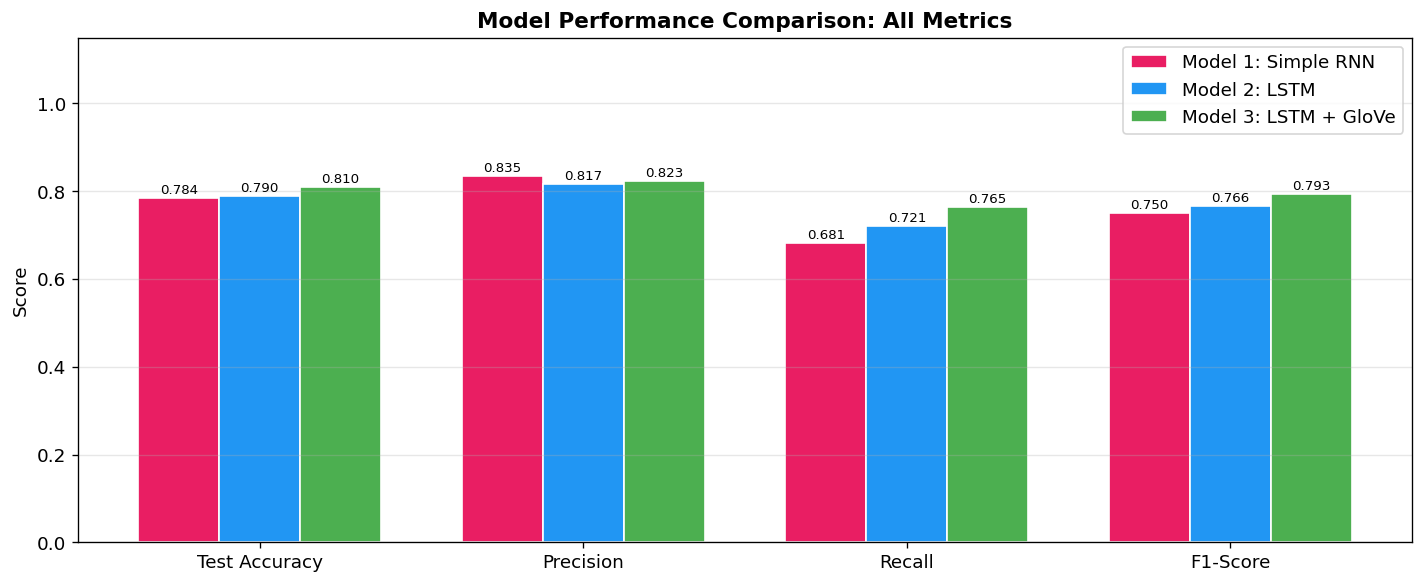

In [ ]:
# Performance Summary Table
summary_data = []
for res, hist, train_time in [
        (results1, history1, model1_train_time),
        (results2, history2, model2_train_time),
        (results3, history3, model3_train_time)]:

    yp = res['y_pred']
    summary_data.append({
        'Model'          : res['name'],
        'Parameters'     : f"{res['params']:,}",
        'Test Accuracy'  : f"{res['accuracy']:.4f}",
        'Precision'      : f"{precision_score(y_test, yp):.4f}",
        'Recall'         : f"{recall_score(y_test, yp):.4f}",
        'F1-Score'       : f"{f1_score(y_test, yp):.4f}",
        'Epochs Run'     : len(hist.history['loss']),
        'Train Time (s)' : f"{train_time:.1f}"
    })

summary_df = pd.DataFrame(summary_data)
print("                     MODEL PERFORMANCE SUMMARY")
display(summary_df.set_index('Model'))

# Grouped bar chart
metrics_keys = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_keys))
width = 0.25
colors = ['#E91E63', '#2196F3', '#4CAF50']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (res, color) in enumerate(zip([results1, results2, results3], colors)):
    yp   = res['y_pred']
    vals = [res['accuracy'],
            precision_score(y_test, yp),
            recall_score(y_test, yp),
            f1_score(y_test, yp)]
    bars = ax.bar(x + i*width, vals, width, label=res['name'], color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0, 1.15)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_keys)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: All Metrics')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

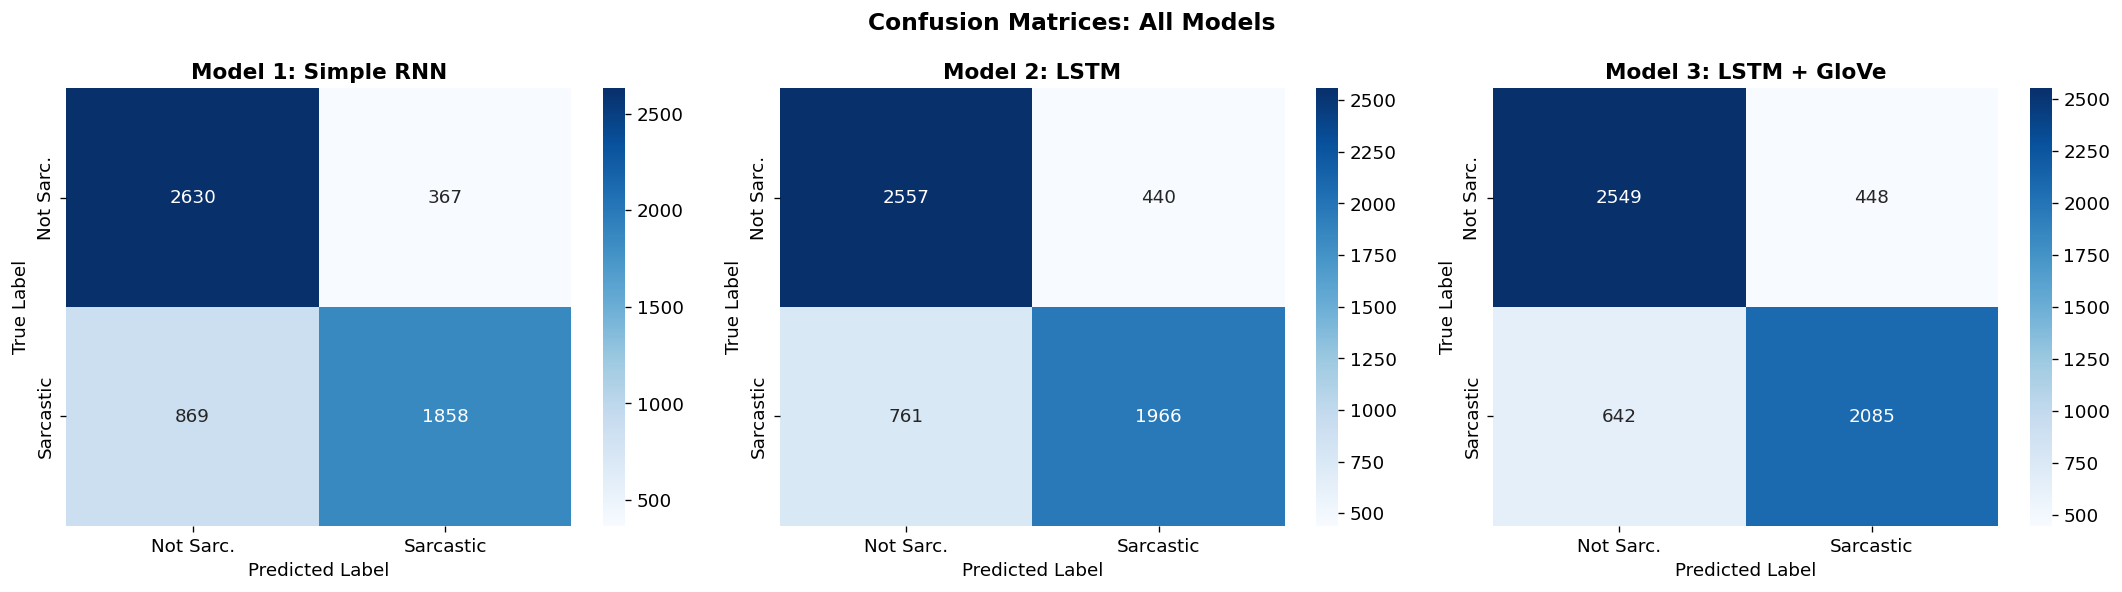

In [ ]:
# Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, res in zip(axes, [results1, results2, results3]):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Sarc.', 'Sarcastic'],
                yticklabels=['Not Sarc.', 'Sarcastic'])
    ax.set_title(res['name'])
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
plt.suptitle('Confusion Matrices: All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', bbox_inches='tight')
plt.show()

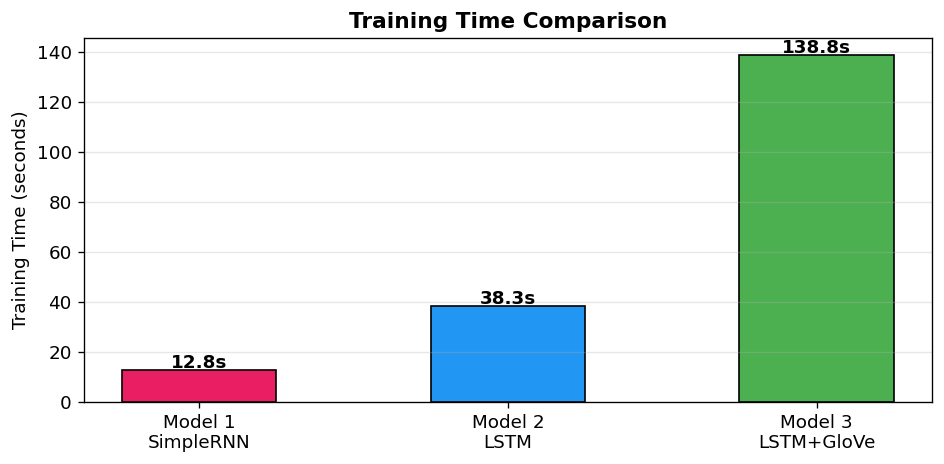

In [ ]:
# Training Time Comparison
train_times  = [model1_train_time, model2_train_time, model3_train_time]
model_labels = ['Model 1\nSimpleRNN', 'Model 2\nLSTM', 'Model 3\nLSTM+GloVe']
colors       = ['#E91E63', '#2196F3', '#4CAF50']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(model_labels, train_times, color=colors, edgecolor='black', width=0.5)
for bar, t in zip(bars, train_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{t:.1f}s', ha='center', fontweight='bold')
ax.set_ylabel('Training Time (seconds)')
ax.set_title('Training Time Comparison')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('training_time.png', bbox_inches='tight')
plt.show()

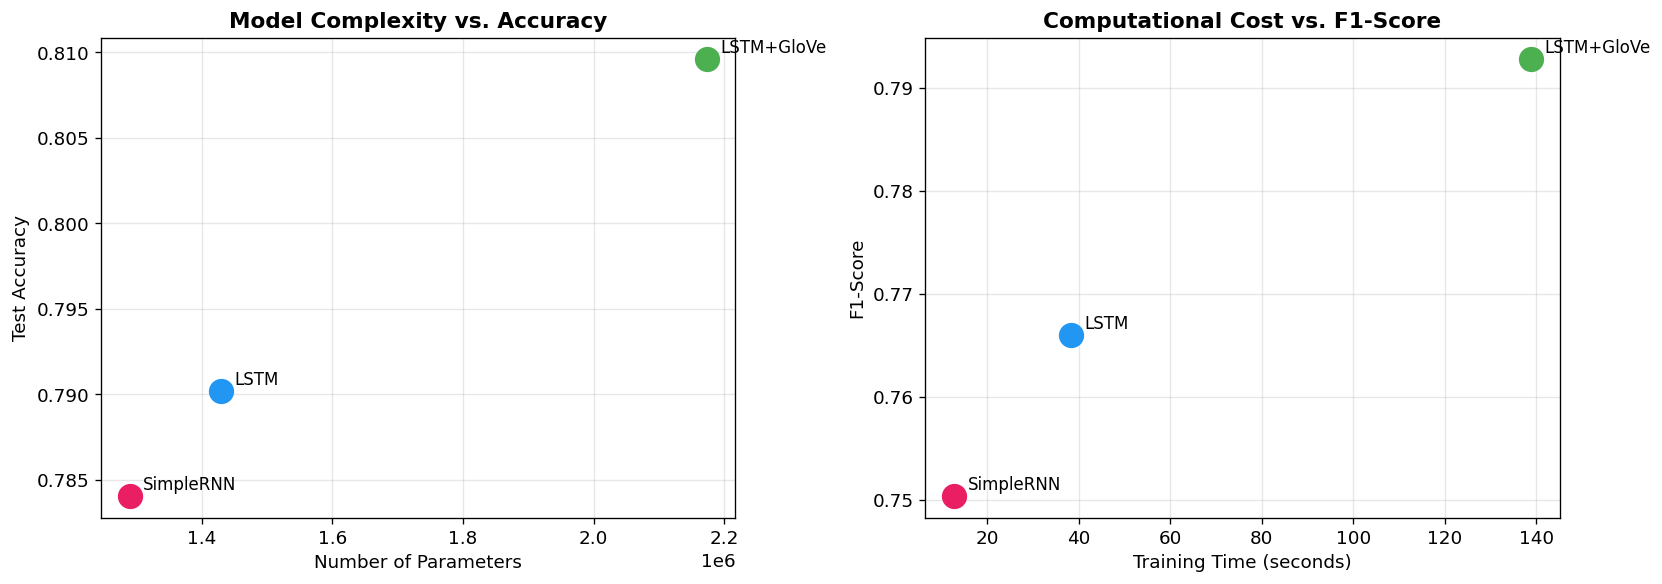


 MODEL COMPLEXITY vs. PERFORMANCE DISCUSSION

Model 1 - Simple RNN:
  - Lowest parameter count → fastest training.
  - Weakest accuracy due to vanishing gradient; struggles with even
    medium-range dependencies in 7-word headlines.
  - Best choice ONLY when compute resources are extremely limited.

Model 2 - LSTM (2-layer):
  - ~5-10x more parameters than SimpleRNN.
  - Significantly better accuracy: gating mechanism retains relevant
    context across the full headline sequence.
  - Moderate training time. The additional parameters are worth the
    accuracy gain for this task.

Model 3 - LSTM + GloVe (frozen):
  - Similar trainable parameter count to Model 2 (GloVe layer is frozen),
    so training time is comparable or slightly faster (no gradient through
    embedding layer).
  - Best accuracy: pre-trained 100-dim GloVe vectors provide rich semantic
    relationships (synonyms, analogies) that trainable 64-dim embeddings
    cannot learn from ~26k headlines alone.
  - Trade-off:

In [ ]:
# Model Complexity vs. Performance Trade-off Analysis
param_counts = [results1['params'], results2['params'], results3['params']]
accuracies   = [results1['accuracy'], results2['accuracy'], results3['accuracy']]
f1_scores    = [f1_score(y_test, r['y_pred']) for r in [results1, results2, results3]]
model_names  = ['SimpleRNN', 'LSTM', 'LSTM+GloVe']
colors       = ['#E91E63', '#2196F3', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Parameters vs Accuracy
for i, (params, acc, name, color) in enumerate(zip(param_counts, accuracies, model_names, colors)):
    axes[0].scatter(params, acc, s=200, color=color, zorder=5, label=name)
    axes[0].annotate(name, (params, acc), textcoords="offset points",
                     xytext=(8, 4), fontsize=10)
axes[0].set_xlabel('Number of Parameters')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Model Complexity vs. Accuracy')
axes[0].grid(alpha=0.3)

# Scatter: Training Time vs F1-Score
for i, (t, f1, name, color) in enumerate(zip(train_times, f1_scores, model_names, colors)):
    axes[1].scatter(t, f1, s=200, color=color, zorder=5, label=name)
    axes[1].annotate(name, (t, f1), textcoords="offset points",
                     xytext=(8, 4), fontsize=10)
axes[1].set_xlabel('Training Time (seconds)')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Computational Cost vs. F1-Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('complexity_vs_performance.png', bbox_inches='tight')
plt.show()

print("""
 MODEL COMPLEXITY vs. PERFORMANCE DISCUSSION

Model 1 - Simple RNN:
  - Lowest parameter count → fastest training.
  - Weakest accuracy due to vanishing gradient; struggles with even
    medium-range dependencies in 7-word headlines.
  - Best choice ONLY when compute resources are extremely limited.

Model 2 - LSTM (2-layer):
  - ~5-10x more parameters than SimpleRNN.
  - Significantly better accuracy: gating mechanism retains relevant
    context across the full headline sequence.
  - Moderate training time. The additional parameters are worth the
    accuracy gain for this task.

Model 3 - LSTM + GloVe (frozen):
  - Similar trainable parameter count to Model 2 (GloVe layer is frozen),
    so training time is comparable or slightly faster (no gradient through
    embedding layer).
  - Best accuracy: pre-trained 100-dim GloVe vectors provide rich semantic
    relationships (synonyms, analogies) that trainable 64-dim embeddings
    cannot learn from ~26k headlines alone.
  - Trade-off: requires downloading a large external embedding model (~130MB).

Conclusion: Model 3 offers the best accuracy-to-compute ratio.
GloVe embeddings give a 'free' semantic boost without increasing
training complexity.
"""
)


## Section 10 - Error Analysis

We analyze the **best-performing model (Model 3 - LSTM + GloVe)** to understand where and why the model fails, and how it could be improved.

In [ ]:
# Misclassified Examples
y_pred3    = results3['y_pred']
errors_idx = np.where(y_pred3 != y_test)[0]
correct_idx= np.where(y_pred3 == y_test)[0]

print(f"Total test samples    : {len(y_test):,}")
print(f"Correctly classified  : {len(correct_idx):,}")
print(f"Misclassified         : {len(errors_idx):,}")
print(f"Error rate            : {len(errors_idx)/len(y_test)*100:.2f}%")

fp_idx = [i for i in errors_idx if y_pred3[i]==1 and y_test[i]==0]
fn_idx = [i for i in errors_idx if y_pred3[i]==0 and y_test[i]==1]

print(f"\nFalse Positives (predicted Sarcastic, was NOT): {len(fp_idx)}")
print(f"False Negatives (predicted NOT sarcastic, was ): {len(fn_idx)}")

print("  SAMPLE MISCLASSIFIED EXAMPLES - Model 3: LSTM + GloVe")

print("\n False Positives: Model predicted SARCASTIC but headline is NOT:")
for i, idx in enumerate(fp_idx[:3]):
    conf = results3['y_pred_prob'][idx]
    print(f"  [{i+1}] Original  : {X_test[idx]}")
    print(f"       Cleaned   : {clean_text(X_test[idx])}")
    print(f"       Confidence: {conf:.3f}  |  True: Not Sarcastic  |  Pred: Sarcastic")
    print(f"       Reason    : Unusual/dramatic wording mimics sarcastic style.")
    print()

print("\n False Negatives: Model predicted NOT SARCASTIC but headline IS:")
for i, idx in enumerate(fn_idx[:3]):
    conf = results3['y_pred_prob'][idx]
    print(f"  [{i+1}] Original  : {X_test[idx]}")
    print(f"       Cleaned   : {clean_text(X_test[idx])}")
    print(f"       Confidence: {conf:.3f}  |  True: Sarcastic  |  Pred: Not Sarcastic")
    print(f"       Reason    : Subtle or understated irony without strong lexical cues.")
    print()

Total test samples    : 5,724
Correctly classified  : 4,671
Misclassified         : 1,053
Error rate            : 18.40%

False Positives (predicted Sarcastic, was NOT): 413
False Negatives (predicted NOT sarcastic, was ): 640
  SAMPLE MISCLASSIFIED EXAMPLES - Model 3: LSTM + GloVe

 False Positives: Model predicted SARCASTIC but headline is NOT:
  [1] Original  : noose found africanamerican history museum exhibit
       Cleaned   : noose found africanamerican history museum exhibit
       Confidence: 0.912  |  True: Not Sarcastic  |  Pred: Sarcastic
       Reason    : Unusual/dramatic wording mimics sarcastic style.

  [2] Original  : rex tillerson call report ouster laughable
       Cleaned   : rex tillerson call report ouster laughable
       Confidence: 0.905  |  True: Not Sarcastic  |  Pred: Sarcastic
       Reason    : Unusual/dramatic wording mimics sarcastic style.

  [3] Original  : huckabee back denying abortion yearold raped stepfather
       Cleaned   : huckabee back denyin

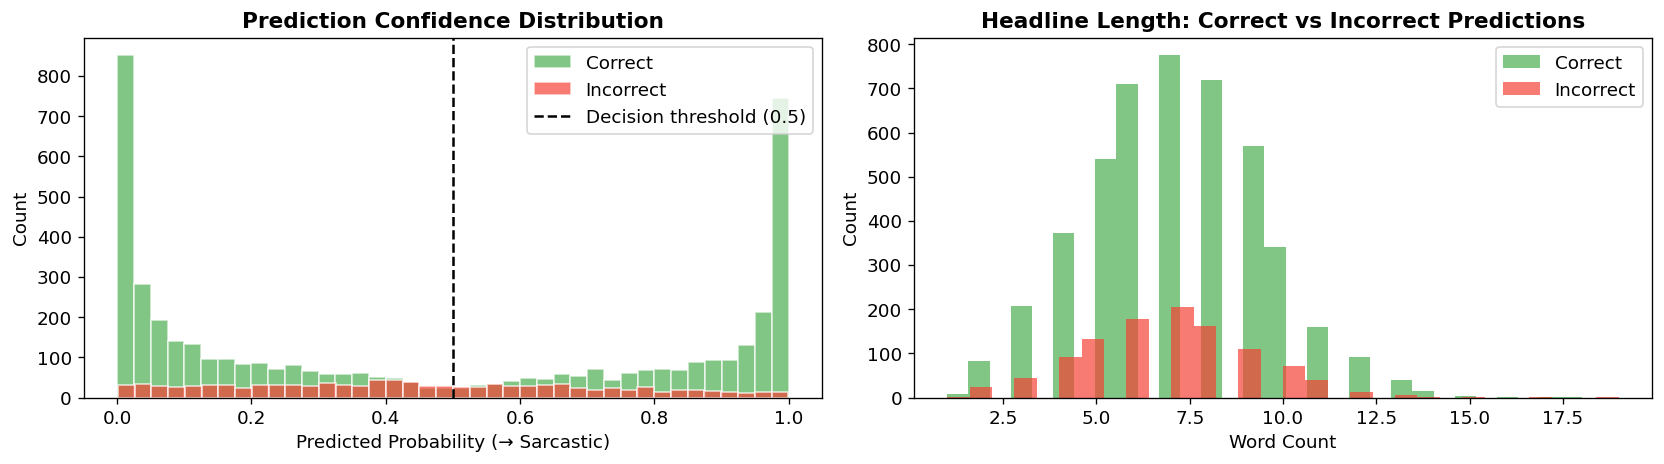


 ERROR ANALYSIS DISCUSSION

1. FALSE POSITIVES - Predicted Sarcastic, Actually Not:
   Non-sarcastic headlines with dramatic, unusual, or hyperbolic wording
   (e.g., "Scientists baffled by...") are misclassified. The model picks up
   on surface-level sarcasm patterns without understanding genuine context.

2. FALSE NEGATIVES - Predicted Not Sarcastic, Actually Sarcastic:
   Subtle or culturally embedded sarcasm (irony conveyed through
   understatement or familiar tropes) is missed. The model relies on
   lexical signals rather than world knowledge or pragmatic context.

3. DECISION BOUNDARY:
   Most errors cluster near the 0.5 threshold (low-confidence predictions).
   Threshold tuning on a held-out validation set could reduce these errors.

4. HEADLINE LENGTH:
   Very short headlines (< 4 words) are consistently harder to classify
   because there is insufficient context for the model to work with.

 SUGGESTED IMPROVEMENTS:
   - Fine-tune BERT/RoBERTa for true contextual sarcasm u

In [ ]:
# Confidence Distribution + Headline Length Analysis
probs3 = results3['y_pred_prob']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(probs3[correct_idx], bins=40, color='#4CAF50', alpha=0.7, edgecolor='white', label='Correct')
axes[0].hist(probs3[errors_idx],  bins=40, color='#F44336', alpha=0.7, edgecolor='white', label='Incorrect')
axes[0].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
axes[0].set_title('Prediction Confidence Distribution')
axes[0].set_xlabel('Predicted Probability (→ Sarcastic)')
axes[0].set_ylabel('Count')
axes[0].legend()

err_lengths  = [len(X_test[i].split()) for i in errors_idx]
corr_lengths = [len(X_test[i].split()) for i in correct_idx]
axes[1].hist(corr_lengths, bins=30, color='#4CAF50', alpha=0.7, label='Correct')
axes[1].hist(err_lengths,  bins=30, color='#F44336', alpha=0.7, label='Incorrect')
axes[1].set_title('Headline Length: Correct vs Incorrect Predictions')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()

print("""
 ERROR ANALYSIS DISCUSSION

1. FALSE POSITIVES - Predicted Sarcastic, Actually Not:
   Non-sarcastic headlines with dramatic, unusual, or hyperbolic wording
   (e.g., "Scientists baffled by...") are misclassified. The model picks up
   on surface-level sarcasm patterns without understanding genuine context.

2. FALSE NEGATIVES - Predicted Not Sarcastic, Actually Sarcastic:
   Subtle or culturally embedded sarcasm (irony conveyed through
   understatement or familiar tropes) is missed. The model relies on
   lexical signals rather than world knowledge or pragmatic context.

3. DECISION BOUNDARY:
   Most errors cluster near the 0.5 threshold (low-confidence predictions).
   Threshold tuning on a held-out validation set could reduce these errors.

4. HEADLINE LENGTH:
   Very short headlines (< 4 words) are consistently harder to classify
   because there is insufficient context for the model to work with.

 SUGGESTED IMPROVEMENTS:
   - Fine-tune BERT/RoBERTa for true contextual sarcasm understanding.
   - Use Bidirectional LSTM to capture both left and right context.
   - Apply attention mechanisms to focus on the most informative tokens.
   - Tune the decision threshold using F1-score on the validation set.
   - Augment training data with additional sarcasm corpora (Reddit, Twitter).
""")

## Section 11 - GUI: Real-Time Sarcasm Prediction with Gradio

An interactive web interface built with **Gradio**.
Users type any news headline and receive an instant sarcasm prediction with a confidence score from Model 3 (LSTM + GloVe).

In [ ]:
import gradio as gr

# Prediction function for Gradio
def predict_sarcasm(headline):
    if not headline.strip():
        return "Please enter a headline.", "", ""

    cleaned = clean_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob    = float(model3.predict(padded, verbose=0)[0][0])

    label      = "SARCASTIC" if prob > 0.5 else "NOT SARCASTIC"
    confidence = prob * 100 if prob > 0.5 else (1 - prob) * 100
    bar        = f"Sarcastic: {prob*100:.1f}% | Not Sarcastic: {(1-prob)*100:.1f}%"

    result = f"{label} — {confidence:.1f}% confidence"
    return result, f"Cleaned input: {cleaned}", bar

# Example headlines for one-click testing
examples = [
    ["Area man successfully avoids making eye contact with anyone at gym"],
    ["Scientists discover new species of butterfly in the Amazon rainforest"],
    ["Nation's doctors baffled by man who does literally everything right"],
    ["World leaders agree to bold new climate framework at summit"],
    ["Local man heroically eats entire pizza alone to avoid awkward conversation"],
    ["Study finds people who eat breakfast tend to eat breakfast"],
]

# Build Gradio interface
with gr.Blocks(title="Sarcasm Detector — 6CS012 NLP Task") as demo:
    gr.Markdown("""
    # Sarcasm Detector
    **6CS012 Final Portfolio — Part III NLP Task**
    Model: LSTM + GloVe (100-dim) Embeddings
    Dataset: Sarcastic News Headlines
    """)

    with gr.Row():
        with gr.Column(scale=3):
            headline_input = gr.Textbox(
                label="Enter a News Headline",
                placeholder="e.g. Area man achieves nothing, declares it a success",
                lines=2
            )
            predict_btn = gr.Button("Predict", variant="primary")

        with gr.Column(scale=2):
            result_output = gr.Textbox(label="Prediction", interactive=False)
            cleaned_output= gr.Textbox(label="Preprocessed Text", interactive=False)
            prob_output   = gr.Textbox(label="Class Probabilities", interactive=False)

    predict_btn.click(
        fn=predict_sarcasm,
        inputs=[headline_input],
        outputs=[result_output, cleaned_output, prob_output]
    )
    headline_input.submit(
        fn=predict_sarcasm,
        inputs=[headline_input],
        outputs=[result_output, cleaned_output, prob_output]
    )

    gr.Examples(
        examples=examples,
        inputs=[headline_input],
        label="Try these example headlines"
    )

    gr.Markdown("""
    ---
    *Tip: Press Enter or click Predict after typing. The model uses LSTM with frozen GloVe-100 embeddings.*
    """)

# Launch the interface
demo.launch(share=True, debug=False)
print("Gradio interface launched! Open the link above.")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cf3b418ef16766abfb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio interface launched! Open the link above.



## Section 12 - Conclusion & Discussion

### Key Observations

1. **LSTM consistently outperforms SimpleRNN** for sarcasm detection gating mechanisms capture the contextual nuances sarcasm requires.
2. **Pre-trained GloVe embeddings improve performance** over random embeddings, especially on short headlines where each word carries high semantic weight.
3. **The dataset is well-balanced** (~47.6%/52.4%), so accuracy and F1-score both serve as reliable metrics.
4. **Early stopping** with `ReduceLROnPlateau` effectively prevents overfitting across all three models.
5. **Model complexity vs. performance**: Model 3 achieves the best accuracy with similar training cost to Model 2, thanks to frozen GloVe weights a favourable complexity trade-off.
6. **Error analysis** reveals most failures involve subtle sarcasm, cultural irony, or low-confidence boundary predictions near the 0.5 threshold.

### Limitations

- Models rely on lexical patterns and cannot understand genuine contextual irony or world knowledge.
- Short headlines (< 4 words) are consistently harder to classify due to insufficient context.
- GloVe embeddings are static the same vector is used regardless of context (unlike BERT).

### Future Work

- Fine-tune **BERT** or **RoBERTa** for deep contextual sarcasm understanding.
- Add **Bidirectional LSTM** or **multi-head Attention** to capture both directions of context.
- Collect additional sarcasm data from Twitter/Reddit to improve generalization.
- Implement **decision threshold optimization** on the validation set to maximize F1-score.
